# 03 — CFL Stability Analysis

Explicit schemes (Leapfrog, RK4) require the **CFL condition**:
$$\Delta t \leq \frac{h}{c\sqrt{d}}$$
where $d=2$ (spatial dimension), $h$ = mesh size, $c$ = wave speed.

Implicit schemes (CN, BE) are **unconditionally stable** — no CFL constraint.

This notebook reads `results/cfl_stability.csv` (from `scripts/cfl_stability_sweep.py`)
and plots E(T)/E(0) vs $\Delta t / \Delta t_{CFL}$ to show:
- Below 1.0: stable, energy conserved
- Above 1.0: unstable, energy explodes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12, 'figure.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
DATA = Path('../results')

try:
    df = pd.read_csv(DATA / 'cfl_stability.csv')
    print(df.to_string(index=False))
except FileNotFoundError:
    print('Run scripts/cfl_stability_sweep.py first')
    df = pd.DataFrame()

  scheme  dt_fraction       dt  energy_ratio   status
Leapfrog         0.50 0.011049  1.044239e+00   STABLE
Leapfrog         0.75 0.016573  1.065144e+00   STABLE
Leapfrog         0.90 0.019887  1.077117e+00   STABLE
Leapfrog         0.95 0.020992  1.088344e+00   STABLE
Leapfrog         1.00 0.022097  6.639625e+54 UNSTABLE
Leapfrog         1.05 0.023202  1.097597e+00   STABLE
Leapfrog         1.10 0.024307  1.103617e+00   STABLE
Leapfrog         1.20 0.026517  1.009444e+52 UNSTABLE
Leapfrog         1.40 0.030936 1.183803e+113 UNSTABLE
Leapfrog         1.60 0.035355 7.511612e+121 UNSTABLE
Leapfrog         2.00 0.044194 1.836096e+110 UNSTABLE
     RK4         0.50 0.011049  1.000000e+00   STABLE
     RK4         0.75 0.016573  9.999997e-01   STABLE
     RK4         0.90 0.019887  9.999993e-01   STABLE
     RK4         0.95 0.020992  9.999991e-01   STABLE
     RK4         1.00 0.022097  9.999989e-01   STABLE
     RK4         1.05 0.023202  9.999986e-01   STABLE
     RK4         1.10 0.0243

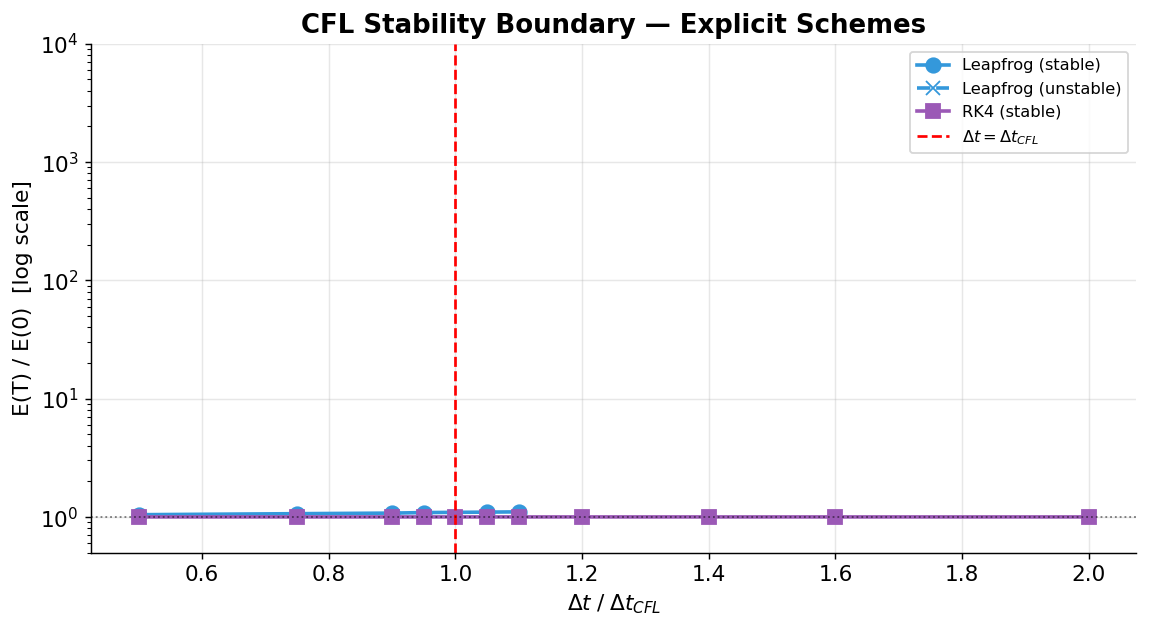

Saved cfl_stability.png

=== Stability Summary ===
  scheme  dt_fraction  energy_ratio   status
Leapfrog         0.50  1.044239e+00   STABLE
Leapfrog         0.75  1.065144e+00   STABLE
Leapfrog         0.90  1.077117e+00   STABLE
Leapfrog         0.95  1.088344e+00   STABLE
Leapfrog         1.00  6.639625e+54 UNSTABLE
Leapfrog         1.05  1.097597e+00   STABLE
Leapfrog         1.10  1.103617e+00   STABLE
Leapfrog         1.20  1.009444e+52 UNSTABLE
Leapfrog         1.40 1.183803e+113 UNSTABLE
Leapfrog         1.60 7.511612e+121 UNSTABLE
Leapfrog         2.00 1.836096e+110 UNSTABLE
     RK4         0.50  1.000000e+00   STABLE
     RK4         0.75  9.999997e-01   STABLE
     RK4         0.90  9.999993e-01   STABLE
     RK4         0.95  9.999991e-01   STABLE
     RK4         1.00  9.999989e-01   STABLE
     RK4         1.05  9.999986e-01   STABLE
     RK4         1.10  9.999982e-01   STABLE
     RK4         1.20  9.999972e-01   STABLE
     RK4         1.40  9.999939e-01   STABLE
    

In [2]:
if not df.empty:
    SCHEME_STYLE = {
        'Leapfrog': dict(color='#3498db', marker='o'),
        'RK4':      dict(color='#9b59b6', marker='s'),
    }

    fig, ax = plt.subplots(figsize=(9, 5))

    for scheme, style in SCHEME_STYLE.items():
        sub = df[df['scheme'] == scheme].sort_values('dt_fraction')
        stable   = sub[sub['energy_ratio'] <  2.0]
        unstable = sub[sub['energy_ratio'] >= 2.0]

        if not stable.empty:
            ax.semilogy(stable['dt_fraction'], stable['energy_ratio'],
                        lw=2, markersize=8, label=f'{scheme} (stable)',
                        **style)
        if not unstable.empty:
            er_clipped = unstable['energy_ratio'].clip(upper=1e6)
            ax.semilogy(unstable['dt_fraction'], er_clipped,
                        lw=2, markersize=8, ls='--',
                        label=f'{scheme} (unstable)',
                        color=style['color'], marker='x')

    ax.axvline(1.0, color='r', ls='--', lw=1.5,
               label=r'$\Delta t = \Delta t_{CFL}$')
    ax.axhline(1.0, color='k', ls=':',  lw=1, alpha=0.5)
    ax.set_xlabel(r'$\Delta t \;/\; \Delta t_{CFL}$')
    ax.set_ylabel('E(T) / E(0)  [log scale]')
    ax.set_title('CFL Stability Boundary — Explicit Schemes', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1e4)

    plt.tight_layout()
    plt.savefig(DATA / 'cfl_stability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved cfl_stability.png')

    # Summary table
    print('\n=== Stability Summary ===')
    print(df[['scheme', 'dt_fraction', 'energy_ratio', 'status']].to_string(index=False))